In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [3]:
load_dotenv()


True

In [5]:

model = ChatGroq(
        model='llama-3.3-70b-versatile',
        temperature=0.7,
        max_tokens=600
    )

In [12]:
class llm_workflow(TypedDict):
    ques:str
    ans:str

In [13]:
def llm_chat(state: llm_workflow) -> llm_workflow:
    ques= state['ques']
    prompt=f'Answer the following Question in brief {ques}'
    
    answer= model.invoke(prompt).content
    state['ans']=answer
    return state


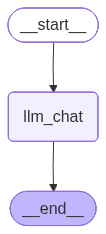

In [14]:
# Define Graph
graph=StateGraph(llm_workflow)
#add node
graph.add_node('llm_chat',llm_chat)

#add edges
graph.add_edge(START,'llm_chat')
graph.add_edge('llm_chat',END)

#compile
workflow=graph.compile()
workflow

In [15]:
initial_state={'ques':'How hot is SUn compared to Earth?'}
out_state=workflow.invoke(initial_state)
out_state

{'ques': 'How hot is SUn compared to Earth?',
 'ans': 'The surface of the Sun is about 5,500°C (10,000°F), while the core is around 15,000,000°C (27,000,000°F). In comparison, the average temperature on Earth is about 15°C (59°F). So, the Sun is approximately 367 times hotter than Earth.'}